
# Plot land-cover change from the REALISTIC surfdata file

This notebook is a lighter version of `Modify-input-surfdata-map_REALISTIC.ipynb`.

It does **not** recreate `pfts_CLM_GFDL` from the LPJ-GUESS text files. Instead, it reads it back from the edited surfdata file you already have:

```text
surfdata_1.9x2.5_hist_78pfts_CMIP6_simyr2000_c190304_GFDL.nc
```

The final plotting call keeps the same structure as the original notebook:

```python
plot_boreal_pfts((pfts_CLM_GFDL-pfts_CLM).sel(natpft=[1,2,3,5,7,8,11,12]), ...)
```


In [8]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# Make the src/ package importable when this notebook is run from analysis/
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "analysis" else Path.cwd().resolve()
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from boreal_forest_expansion.plotting.pfts import plot_boreal_pfts, basic_pft_map
from boreal_forest_expansion.plotting.common import dict_to_legend, plot_title
from boreal_forest_expansion.plotting.style import set_default_style
from boreal_forest_expansion.plotting.palette import diverging_colormap

set_default_style()
xr.set_options(display_style="html")


## File paths

Adjust `SURFDATA_DIR` only if your `data/` directory is not at the project root.


In [2]:

# Expected layout if this notebook lives in analysis/:
# project/
# ├── analysis/plot-lcc.ipynb
# ├── data/surfdatamap/<original surfdata>.nc
# └── processed-data/input/REALISTIC/<edited surfdata>_GFDL.nc
original_surfdata_file = '/cluster/shared/noresm/inputdata/lnd/clm2/surfdata_map/release-clm5.0.18/surfdata_1.9x2.5_hist_78pfts_CMIP6_simyr2000_c190304.nc'
gfdl_surfdata_file = '/cluster/shared/noresm/inputdata/lnd/clm2/surfdata_map/surfdata_1.9x2.5_78pfts_LPJGUESS_SSP585.nc'

print("Original surfdata:", original_surfdata_file)
print("GFDL edited surfdata:", gfdl_surfdata_file)


Original surfdata: /cluster/shared/noresm/inputdata/lnd/clm2/surfdata_map/release-clm5.0.18/surfdata_1.9x2.5_hist_78pfts_CMIP6_simyr2000_c190304.nc
GFDL edited surfdata: /cluster/shared/noresm/inputdata/lnd/clm2/surfdata_map/surfdata_1.9x2.5_78pfts_LPJGUESS_SSP585.nc



## Coordinate helpers

The old notebook used:

```python
convert180_360(convert_lsmcoord(ds)).PCT_NAT_PFT
```

If those functions have been moved into `boreal_forest_expansion.core.coordinates`, this cell imports them. If not, it defines small local equivalents for this plotting-only workflow.


In [3]:

try:
    from boreal_forest_expansion.core.coordinates import convert_lsmcoord, convert180_360
except Exception:
    def convert_lsmcoord(ds):
        "Convert CLM surfdata lsmlat/lsmlon dimensions to lat/lon coordinates."
        ds = ds.copy()

        rename = {}
        if "lsmlat" in ds.dims:
            rename["lsmlat"] = "lat"
        if "lsmlon" in ds.dims:
            rename["lsmlon"] = "lon"
        if rename:
            ds = ds.rename(rename)

        # CLM surfdata usually stores 2-D LATIXY/LONGXY. For regular grids,
        # one row/column is enough to reconstruct 1-D lat/lon coordinates.
        if "LATIXY" in ds and "lat" in ds.dims:
            lat = ds["LATIXY"]
            if lat.ndim == 2:
                lat = lat.isel(lon=0)
            ds = ds.assign_coords(lat=lat.values)

        if "LONGXY" in ds and "lon" in ds.dims:
            lon = ds["LONGXY"]
            if lon.ndim == 2:
                lon = lon.isel(lat=0)
            ds = ds.assign_coords(lon=lon.values)

        return ds

    def convert180_360(ds):
        "Convert longitude coordinates from -180..180 to 0..360 and sort."
        ds = ds.copy()
        if "lon" not in ds.coords:
            return ds
        lon = ds["lon"]
        if float(lon.min()) < 0:
            ds = ds.assign_coords(lon=(lon % 360)).sortby("lon")
        return ds



## Import original and edited surfdata

This recreates the old variables, but now directly from the two surfdata files:

- `pfts_CLM`: original `PCT_NAT_PFT`
- `pfts_CLM_GFDL`: edited `PCT_NAT_PFT` stored inside `*_GFDL.nc`


In [4]:

# Open original and edited surfdata files
dset_in = xr.open_dataset(original_surfdata_file)
ds = xr.open_dataset(gfdl_surfdata_file)

# Same extraction pattern as in the previous notebook, but using the saved GFDL file.
pfts_CLM = convert180_360(convert_lsmcoord(dset_in)).PCT_NAT_PFT
pfts_CLM_GFDL = convert180_360(convert_lsmcoord(ds)).PCT_NAT_PFT

# Optional land mask, if available in the surfdata file.
# This keeps ocean grid cells as NaN for cleaner plotting.
if "LANDFRAC_PFT" in dset_in:
    lnd_frac = convert180_360(convert_lsmcoord(dset_in)).LANDFRAC_PFT
    lnd_frac = lnd_frac.where(lnd_frac <= 1.0, 1.0)
    pfts_CLM = pfts_CLM.where(lnd_frac > 0.0)
    pfts_CLM_GFDL = pfts_CLM_GFDL.where(lnd_frac > 0.0)

pfts_CLM


<xarray.DataArray 'PCT_NAT_PFT' (natpft: 15, lat: 96, lon: 144)> Size: 2MB
array([[[100., 100., 100., ..., 100., 100., 100.],
        [100., 100., 100., ..., 100., 100., 100.],
        [100., 100., 100., ..., 100., 100., 100.],
        ...,
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        ...,
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        ...,
...
        ...,
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        ...,
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        ...,
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]]])
Coordinates:
  * natpft   (natpft) int32 60B 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14
  * lat      (lat) float64 768B -90.0 -88.11 -86.21 -84.32 ... 86.21 88.11 90.0
  * lon      (lon) float64 1kB 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
Attributes:
    long_name:  percent plant functional type on the natural veg landunit (% ...
    units:      unitless

In [5]:

titles = ["1 – TeNET", "2 – BoNET", "3 – BoNDT", "5 – TeBET", "7 – TeBDT", "8 – BoBDT", "11 – BoBDS", "12 – aC3"]
pftnames_CLM = {
    0: "Bare Ground",
    1: "TeNET",
    2: "BoNET",
    3: "BoNDT",
    4: "TrBET",
    5: "TeBET",
    6: "TrBDT",
    7: "TeBDT",
    8: "BoBDT",
    9: "TeBES",
    10: "TeBDS",
    11: "BoBDS",
    12: "arcticC3",
    13: "C3",
    14: "C4",
}

pfts_to_plot = [1, 2, 3, 5, 7, 8, 11, 12]



## Quick checks

These checks are not required for plotting, but they help verify that the saved edited surfdata file really contains the modified PFT distribution.


In [6]:

change = (pfts_CLM_GFDL - pfts_CLM).sel(natpft=pfts_to_plot)

print("Original PFT array:", pfts_CLM.shape)
print("GFDL PFT array:", pfts_CLM_GFDL.shape)
print("Selected change min/max:", float(change.min(skipna=True)), float(change.max(skipna=True)))
print("Selected natpft:", list(change.natpft.values))


Original PFT array: (15, 96, 144)
GFDL PFT array: (15, 96, 144)
Selected change min/max: -48.834726500937535 61.856955481728896
Selected natpft: [1, 2, 3, 5, 7, 8, 11, 12]



## Plot

This is the line from the original notebook, with `pfts_CLM_GFDL` now loaded from the edited surfdata file.


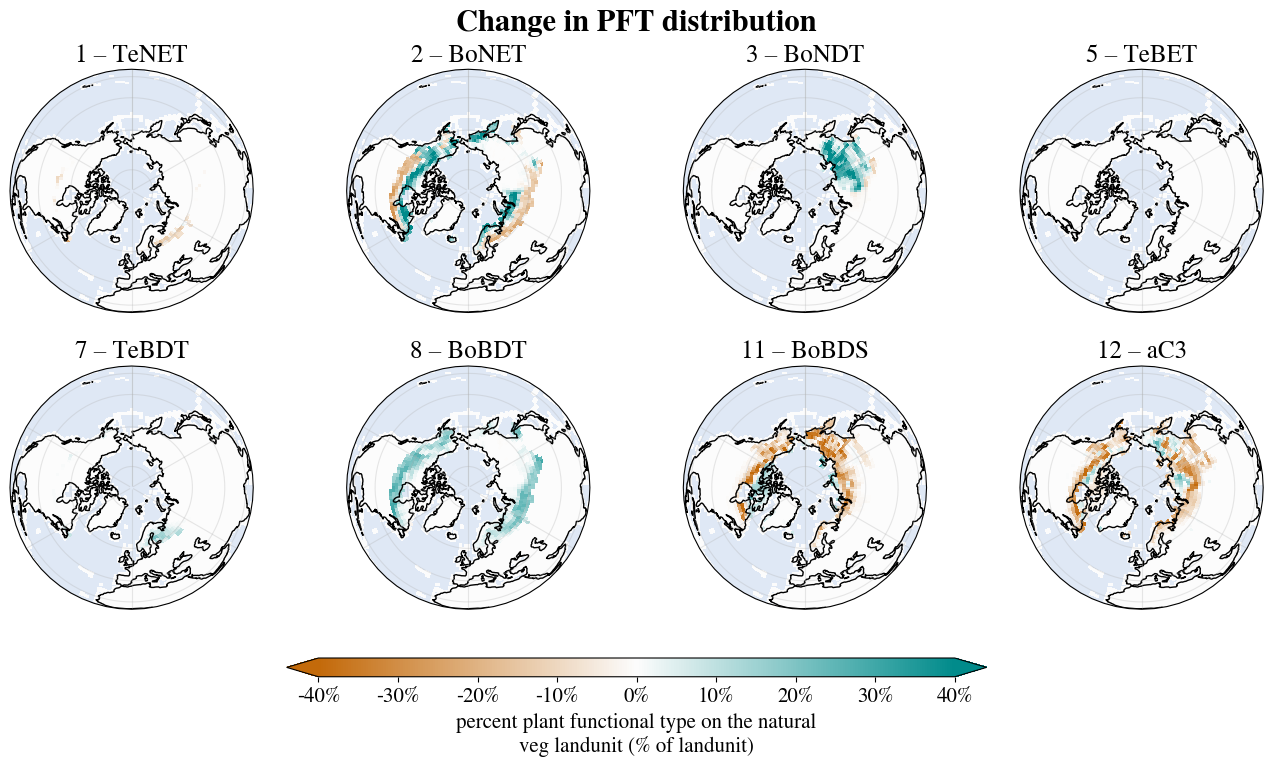

In [18]:
pft_change_cmap = diverging_colormap(
    '#c46a0a',  # vivid brown-orange
    '#018c8c',  # vivid teal
    '#fdfdfd'
)

fig, axes = plot_boreal_pfts(
    (pfts_CLM_GFDL - pfts_CLM).sel(natpft=[1,2,3,5,7,8,11,12]),
    extra_cbar_axis=True,
    title="Change in PFT distribution",
    cmap=pft_change_cmap,
    col_wrap=4,
    titles=titles,
    figsize=(14, 7.5),
    vmin=-40,
    vmax=40,
    show=False
)

fig.savefig(
    "change_pft_distribution.pdf",
    bbox_inches="tight"
)

plt.show()



## Optional: plot the new configuration itself

This mirrors the exploratory cell at the end of the previous notebook.


In [ ]:

plot_boreal_pfts(pfts_CLM_GFDL.sel(natpft=[1,2,3,5,7,8,11,12]),
                 title="New configuration in CLM", col_wrap=4, titles=titles)
